# Association Rule Learning on the Groceries Dataset
**Unsupervised Learning Method-Assignment II**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option("display.max_colwidth", 80)

## Load the data

The **groceries.csv** file is a *basket format* file: each row is one
transaction (shopping basket), and each column holds one purchased item.
Rows are ragged (different numbers of items per transaction), so we read it
as raw text and split each line into a list of items rather than using
pandas' normal rectangular CSV reader.

In [2]:
RAW_PATH = "groceries.csv"

transactions = []
with open(RAW_PATH, "r", encoding="utf-8") as f:
    for line in f:
        items = [item.strip() for item in line.strip().split(",") if item.strip() != ""]
        if items:
            transactions.append(items)

print(f"Number of transactions loaded: {len(transactions)}")
transactions[:3]

Number of transactions loaded: 9835


[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk']]

## Question 1: Understand the Data

a. How many transactions are in the dataset?
b. How many different grocery items are included?
c. What are the 10 most frequently purchased items?

In [3]:
n_transactions = len(transactions)

all_items = [item for basket in transactions for item in basket]
unique_items = sorted(set(all_items))
n_items = len(unique_items)

item_counts = pd.Series(all_items).value_counts()
top10_items = item_counts.head(10)

print(f"a. Number of transactions: {n_transactions}")
print(f"b. Number of different items: {n_items}")
print("c. Top 10 most frequent items:")
top10_items

a. Number of transactions: 9835
b. Number of different items: 169
c. Top 10 most frequent items:


whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
bottled water       1087
root vegetables     1072
tropical fruit      1032
shopping bags        969
sausage              924
Name: count, dtype: int64

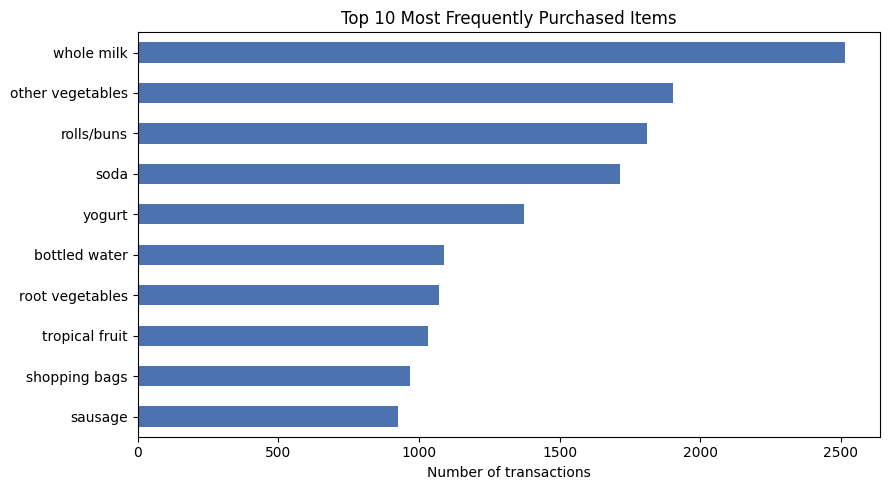

In [4]:
plt.figure(figsize=(9, 5))
top10_items.sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Number of transactions")
plt.title("Top 10 Most Frequently Purchased Items")
plt.tight_layout()
plt.savefig("figures/fig1_top10_items.png", dpi=150)
plt.show()

**Interpretation:** Whole milk is purchased in about 25.6% of all
transactions, making it by far the single most common item, followed by
other vegetables and rolls/buns. These are staple, high-frequency-purchase
items, which is typical of grocery data.

## Question 2: Frequent Itemsets

a. Find at least 10 frequent itemsets containing two or more products.
b. Report their support values.
c. Which itemset has the highest support?
d. What does the support value tell you about customers' purchasing behavior?

In [5]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)
df_onehot.shape

(9835, 169)

In [6]:
# Minimum support chosen low enough to surface a healthy number of
# multi-item itemsets in a sparse basket dataset (9,835 transactions,
# 169 items).
MIN_SUPPORT = 0.01

frequent_itemsets = apriori(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets["itemsets_str"] = frequent_itemsets["itemsets"].apply(
    lambda x: ", ".join(sorted(x))
)

# Itemsets with 2+ products, sorted by support
multi_itemsets = (
    frequent_itemsets[frequent_itemsets["length"] >= 2]
    .sort_values("support", ascending=False)
    .reset_index(drop=True)
)

print(f"Total frequent itemsets found (support >= {MIN_SUPPORT}): {len(frequent_itemsets)}")
print(f"Multi-item (2+) frequent itemsets found: {len(multi_itemsets)}")
multi_itemsets[["itemsets_str", "support"]].head(15)

Total frequent itemsets found (support >= 0.01): 333
Multi-item (2+) frequent itemsets found: 245


,itemsets_str,support
0,"other vegetables, whole milk",0.074835
1,"rolls/buns, whole milk",0.056634
2,"whole milk, yogurt",0.056024
3,"root vegetables, whole milk",0.048907
4,"other vegetables, root vegetables",0.047382
5,"other vegetables, yogurt",0.043416
6,"other vegetables, rolls/buns",0.042603
7,"tropical fruit, whole milk",0.042298
8,"soda, whole milk",0.040061
9,"rolls/buns, soda",0.038332


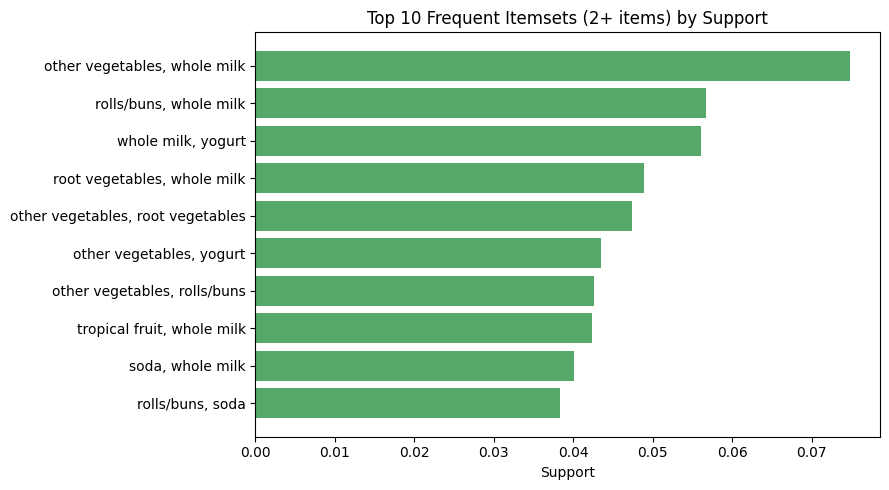

In [7]:
top10_itemsets = multi_itemsets.head(10)
plt.figure(figsize=(9, 5))
plt.barh(top10_itemsets["itemsets_str"][::-1], top10_itemsets["support"][::-1], color="#55A868")
plt.xlabel("Support")
plt.title("Top 10 Frequent Itemsets (2+ items) by Support")
plt.tight_layout()
plt.savefig("figures/fig2_top10_itemsets.png", dpi=150)
plt.show()

**c. Highest-support itemset:** `{other vegetables, whole milk}`, with a
support of ≈0.0748 (about 7.5% of all transactions).

**d. What the support value tells us:** Support measures how frequently an
itemset appears across all transactions. A support of 0.0748 for
`{other vegetables, whole milk}` means that roughly 1 in every 13 shopping
trips includes both items together. High-support itemsets like this reveal
the store's staple combinations — items that a large share of the customer
base buys together regularly, largely because they are everyday household
essentials rather than niche or seasonal products.

## Question 3: Association Rules

Generate at least 10 association rules and report antecedent, consequent,
support, confidence, and lift for each.

In [8]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules[rules["lift"] > 1]  # keep only genuinely useful (positively correlated) rules

rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))

rules_sorted = rules.sort_values("lift", ascending=False).reset_index(drop=True)

report_cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]

print(f"Total rules generated (confidence >= 0.2, lift > 1): {len(rules_sorted)}")
rules_sorted[report_cols].head(10)

Total rules generated (confidence >= 0.2, lift > 1): 231


,antecedents_str,consequents_str,support,confidence,lift
0,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
1,"other vegetables, yogurt",whipped/sour cream,0.010168,0.234192,3.267062
2,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
3,beef,root vegetables,0.017387,0.331395,3.040367
4,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
5,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
6,"other vegetables, whole milk",root vegetables,0.023183,0.309783,2.842082
7,root vegetables,"other vegetables, whole milk",0.023183,0.212687,2.842082
8,butter,"other vegetables, whole milk",0.011490,0.207339,2.770630
9,"curd, whole milk",yogurt,0.010066,0.385214,2.761356


## Question 5: Find Interesting Rules

a. Identify the rule with the highest confidence.
b. Identify the rule with the highest lift.
c. Identify the rule with the highest support.
d. Are these the same rule? Explain.

*(Question 4's written explanation of support/confidence/lift for three
chosen rules, and Questions 6–8's discussion, are qualitative and are
answered in the accompanying report — this notebook computes the
quantitative results they rely on.)*

In [9]:
rule_highest_conf = rules_sorted.loc[rules_sorted["confidence"].idxmax()]
rule_highest_lift = rules_sorted.loc[rules_sorted["lift"].idxmax()]
rule_highest_support = rules_sorted.loc[rules_sorted["support"].idxmax()]

summary_rules = pd.DataFrame(
    [rule_highest_conf[report_cols], rule_highest_lift[report_cols], rule_highest_support[report_cols]],
    index=["Highest confidence", "Highest lift", "Highest support"],
)
summary_rules

,antecedents_str,consequents_str,support,confidence,lift
Highest confidence,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
Highest lift,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
Highest support,other vegetables,whole milk,0.074835,0.386758,1.513634


**d. Are these the same rule?** No — each metric surfaces a different rule.
The highest-support rule (*{other vegetables} → {whole milk}*) is driven by
how popular both items are individually (lift only 1.51), while the
highest-confidence and highest-lift rules both involve smaller, more
specific itemsets (citrus fruit, root vegetables) that co-occur unusually
often relative to their individual frequencies, even though their overall
support is low (~1%).

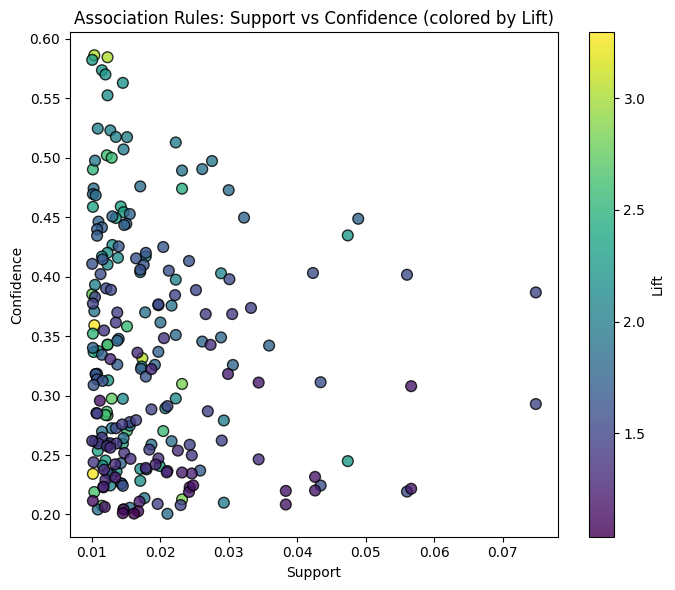

In [10]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    rules_sorted["support"],
    rules_sorted["confidence"],
    c=rules_sorted["lift"],
    cmap="viridis",
    s=60,
    edgecolor="k",
    alpha=0.8,
)
plt.colorbar(sc, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs Confidence (colored by Lift)")
plt.tight_layout()
plt.savefig("figures/fig3_rules_scatter.png", dpi=150)
plt.show()

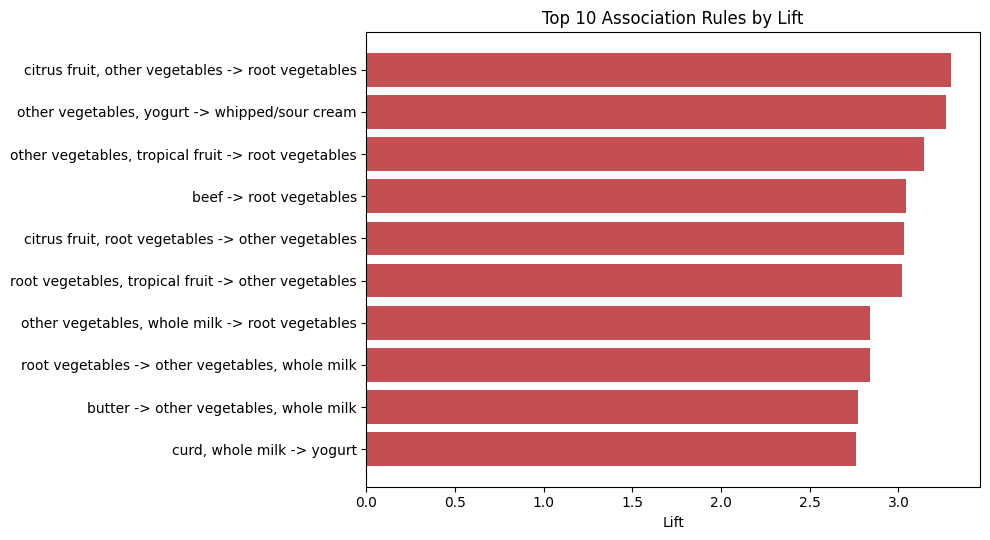

In [11]:
top10_lift = rules_sorted.head(10).copy()
top10_lift["rule_label"] = top10_lift["antecedents_str"] + " -> " + top10_lift["consequents_str"]
plt.figure(figsize=(10, 5.5))
plt.barh(top10_lift["rule_label"][::-1], top10_lift["lift"][::-1], color="#C44E52")
plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift")
plt.tight_layout()
plt.savefig("figures/fig4_top10_rules_lift.png", dpi=150)
plt.show()

## Export tables

Save the key tables as CSV files for inclusion in the written report.

In [12]:
top10_items.to_frame("frequency").to_csv("top10_items.csv")
multi_itemsets[["itemsets_str", "support"]].head(15).to_csv("top15_frequent_itemsets.csv", index=False)
rules_sorted[report_cols].head(15).to_csv("top15_rules.csv", index=False)
summary_rules.to_csv("q5_summary_rules.csv")

print("Tables (CSV) and figures (PNG) have been saved to disk.")

Tables (CSV) and figures (PNG) have been saved to disk.
